In [ ]:
# %pip install langchain langgraph pandas ragas sentence-transformers -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

df = pd.read_csv("../tugas-1/gofood_dataset.csv")
# Filter out columns if needed
df = df[['merchant_name', 'merchant_area', 'category', 'product', 'price']]
df.columns.tolist()

# Take only 5000 rows for faster processing and keep a copy for indexing
df = df.head(5000).copy()
df["row_id"] = df.index

In [2]:
df.to_csv("gofood_5000_sample.csv", index=False)

In [3]:
from langchain_core.documents import Document

# Group rows so each restaurant-category pair shares a single document
grouped = (
    df.groupby(["merchant_name", "category"], as_index=False)
      .agg({
          "merchant_area": "first",
          "product": list,
          "price": list,
          "row_id": list,
      })
)

documents = []
for _, row in grouped.iterrows():
    restaurant_name = str(row['merchant_name'])
    category = str(row['category'])
    products = [str(p) for p in row['product']]
    prices = [str(p) for p in row['price']]

    product_lines = "\n".join(
        f"- {product} | Harga: {price}"
        for product, price in zip(products[:5], prices[:5])
    ) or "- (Produk belum tersedia)"

    text = f"""
    Pertanyaan: Saya ingin {category}. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: {restaurant_name}\nKategori: {category}\nProduk & Harga:\n{product_lines}
    """
    documents.append(
        Document(
            page_content=text,
            metadata={
                "source_rows": [int(idx) for idx in row['row_id']],
                "merchant_area": str(row['merchant_area'])
            }
        )
    )

print(f"Total documents: {len(documents)}")
print(f"Sample document:\n{documents[0].page_content}")
print(f"Metadata of sample document:\n{documents[0].metadata}")

Total documents: 79
Sample document:

    Pertanyaan: Saya ingin Kopi/Minuman/Roti. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: 330 Kopi, Ciledug
Kategori: Kopi/Minuman/Roti
Produk & Harga:
- Hot Almara Kopi (kopi Susu Gula Aren) | Harga: 20000.0
- Ice Almara Kopi (kopi Susu Gula Aren) | Harga: 22000.0
- Hot Millsis | Harga: 20000.0
- Ice Millsis | Harga: 20000.0
- Hot Millbro | Harga: 22000.0
    
Metadata of sample document:
{'source_rows': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63], 'merchant_area': 'jakarta'}


In [10]:
# %pip install langchain-ollama -qU
import torch
from langchain_ollama import ChatOllama
from peft import PeftModel
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          DataCollatorForLanguageModeling, Trainer, TrainingArguments)
MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0" 
OUTPUT_DIR = "tinyllama-gofood-lora"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

def pick_device():
    if hasattr(torch, "accelerator") and torch.accelerator.current_accelerator():
        return torch.accelerator.current_accelerator().type
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = pick_device()
print(f"Using device: {device}")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map=device,
    torch_dtype=torch_dtype
)
model_to_test = PeftModel.from_pretrained(base_model, OUTPUT_DIR)

# jika Ollama serve default di localhost:11434, wrapper akan memakai itu
llm = ChatOllama(model="gpt-oss:120b-cloud")  # ganti model sesuai yang sudah kamu pull
print(llm)
print(model_to_test.peft_config)

Using device: cuda
model='gpt-oss:120b-cloud'
{'default': LoraConfig(peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, base_model_name_or_path='TinyLlama/TinyLlama-1.1B-Chat-v1.0', revision=None, task_type='CAUSAL_LM', inference_mode=True, r=16, target_modules={'k_proj', 'v_proj', 'q_proj', 'o_proj'}, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', loftq_config={}, use_dora=False, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False))}


In [11]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(
    model="all-minilm:22m",
)
print(embeddings)

model='all-minilm:22m' validate_model_on_init=False base_url=None client_kwargs={} async_client_kwargs={} sync_client_kwargs={} mirostat=None mirostat_eta=None mirostat_tau=None num_ctx=None num_gpu=None keep_alive=None num_thread=None repeat_last_n=None repeat_penalty=None temperature=None stop=None tfs_z=None top_k=None top_p=None


In [12]:
# Create a vector store with a sample text
from langchain_core.vectorstores import InMemoryVectorStore

vectorstore = InMemoryVectorStore.from_documents(
    documents,
    embedding=embeddings,
)

# Use the vectorstore as a retriever
retriever = vectorstore.as_retriever()

# Retrieve the most similar text
retrieved_documents = retriever.invoke("Saya ingin ayam")

# Show the retrieved document's content and metadata
print("Retrieved Document Content:")
print(retrieved_documents[0].page_content)
print(retrieved_documents[0].metadata)

Retrieved Document Content:

    Pertanyaan: Saya ingin Aneka nasi/Ayam & bebek/Seafood. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Ayam Trolok
Kategori: Aneka nasi/Ayam & bebek/Seafood
Produk & Harga:
- Ayam Full | Harga: 100000.0
- Nasi | Harga: 6000.0
- Ayam Dada | Harga: 25000.0
- Ayam Paha | Harga: 25000.0
- Kepala Ayam | Harga: 6000.0
    
{'source_rows': [259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275], 'merchant_area': 'jakarta'}


In [13]:
docs_with_scores = vectorstore.similarity_search_with_score("Saya ingin bakso", k=5)
for doc, score in docs_with_scores:
    print(f"Content: {doc.page_content}")
    print(f"Score: {score:.3f}")  # Lower = more similar
    print("---")


Content: 
    Pertanyaan: Saya ingin Bakso & soto/Minuman. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Bakso Titoti, Parung
Kategori: Bakso & soto/Minuman
Produk & Harga:
- Ayam Kampung Goreng Kremes | Harga: 31500.0
- Ayam Kampung Goreng Kremes + Nasi | Harga: 36500.0
- Bakso Mie Campur | Harga: 29000.0
- Bakso Soun/Bihun/Mie Kuning | Harga: 29000.0
- Bakso Spesial | Harga: 39000.0
    
Score: 0.481
---
Content: 
    Pertanyaan: Saya ingin Roti. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Cake Pandeglang Cake
Kategori: Roti
Produk & Harga:
- BF Love Cok Tempel Uk 20cm | Harga: 155000.0
- Bf Kotak Cok Tempel Uk 20cm | Harga: 155000.0
- BF Bulat Ukir Tayo Uk20cm | Harga: 160000.0
- BF Bulat Ukir Doraemon Uk20cm | Harga: 160000.0
- Bf Bulat Ukir Hello Kitty Uk20cm | Harga: 160000.0
    
Score: 0.438
---
Content: 
    Pertanyaan: Saya ingin Ay

In [14]:
from textwrap import shorten

SYSTEM_INSTR="""
Kamu adalah asisten yang sangat membantu untuk merekomendasikan tempat makan berdasarkan keinginan pengguna.

Kamu akan memberikan rekomendasi tempat makan yang sesuai dengan keinginan pengguna berdasarkan data yang kamu miliki.

Susun ulang dengan bahasa yang menarik dan informatif.
Jika tidak ada rekomendasi yang sesuai, katakan bahwa "Mohon maaf, tidak dapat menemukan rekomendasi yang sesuai."
"""

def build_prompt(user_q, retrieved, prompt_tambahan):
    # build a context string listing retrieved items with small excerpts
    context_blocks = []
    for i, r in enumerate(retrieved, 1):
        # limit length to avoid too long prompt
        context_blocks.append(f"[{i}] {str(r)}")
    context = "\n\n".join(context_blocks)
    prompt = (
        SYSTEM_INSTR + "\n\n" +
        f"Context (reference QA pairs):\n{context}\n\n"
        f"Pertanyaan pengguna: {user_q}\n\n" + prompt_tambahan
    )
    # print (prompt)
    return prompt


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 6b69284a-ef73-4c0e-b3f3-44dbb97bd6d9)')' thrown while requesting HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/config.json
Retrying in 1s [Retry 1/5].


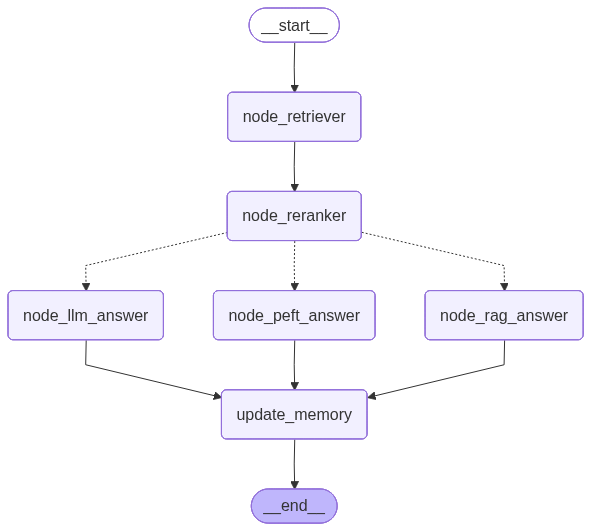

In [93]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from ragas.metrics.collections import BleuScore
from IPython.display import Image
import uuid
from sentence_transformers import CrossEncoder
from transformers import AutoTokenizer

cross_encoder_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# --- STATE DEFINITION ---
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    query: str
    answer: list[BaseMessage]
    llm_answer: list[BaseMessage]
    peft_answer: str
    score: float
    k: int
    retrieved: list[str]
    prompt: str
    bleu_score: float
    next_node: list[str]

# --- INITIALIZE MEMORY AND STORE ---
checkpointer = InMemorySaver()
in_memory_store = InMemoryStore()

# --- NODES ---
def node_retriever(state: State):
    query = state.get("query") or (state["messages"][-1].content if state["messages"] else "")
    k = state.get("k", 3)
    docs_with_score = vectorstore.similarity_search_with_score(query, k)
    best_idx = docs_with_score.index(max(docs_with_score, key=lambda x: x[1]))
    best_score = float(docs_with_score[best_idx][1])
    retrieved_list = [doc.page_content for doc, score in docs_with_score]
    return {"retrieved": retrieved_list, "score": best_score, "query": query}

def router(state: State):
    return ["node_rag_answer", "node_llm_answer", "node_peft_answer"]

async def node_llm_answer(state: State, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"].get("user_id", "default")
    namespace = (user_id, "memories")
    
    q = state["query"]
    memories = store.search(namespace, query=q, limit=3)
    info = "\n".join([d.value["memory"] for d in memories])
    
    prompt = build_prompt(f"Memories: {info}\nQuestion: {q}", [], "Jawab pertanyaan di atas dengan singkat dan jelas.")
    llm_out = await llm.ainvoke([{"role": "user", "content": prompt}])
    
    msg = HumanMessage(content=llm_out.content)
    return {"llm_answer": [msg], "messages": [msg], "prompt": prompt}

async def node_rag_answer(state: State, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"].get("user_id", "default")
    namespace = (user_id, "memories")
    
    q = state["query"]
    retrieved = state["retrieved"]
    
    memories = store.search(namespace, query=q, limit=3)
    info = "\n".join([d.value["memory"] for d in memories])
    
    prompt_tambahan = f"Memories: {info}\nGunakan konteks di atas sebagai dasar jawaban kamu, rekomendasikan cara memesan dan langkah selanjutnya."
    prompt = build_prompt(q, retrieved, prompt_tambahan)

    llm_out = await llm.ainvoke([{"role": "user", "content": prompt}])
    
    # Simple BLEU calculation logic
    scorer = BleuScore()
    score_res = await scorer.ascore(reference="\n".join(retrieved), response=llm_out.content)
    bleu_score = score_res.value if hasattr(score_res, "value") else float(score_res)
    msg = HumanMessage(content=llm_out.content)
    return {"answer": [msg], "messages": [msg], "bleu_score": bleu_score}

def update_memory(state: State, config: RunnableConfig, *, store: BaseStore):

    # Get the user id from the config
    user_id = config["configurable"]["user_id"]

    # Namespace the memory
    namespace = (user_id, "memories")

    # ... Analyze conversation and create a new memory
    memory = ""
    memory = state["messages"][-1].content 
    
    # Create a new memory ID
    memory_id = str(uuid.uuid4())

    # We create a new memory
    store.put(namespace, memory_id, {"memory": memory})
    return {"messages": state["messages"]}

# Retriever reranker
def node_reranker(state: State):
    query = state["query"]
    retrieved = state["retrieved"]
    k = state.get("k", 3)
    
    # Pair up the query + documents
    pairs = [[query, doc] for doc in retrieved]
    
    # Score with CrossEncoder
    scores = cross_encoder_model.predict(pairs)
    
    # Sort/Rerank
    scored_docs = sorted(zip(retrieved, scores), key=lambda x: x[1], reverse=True)
    
    # Take top k
    reranked_docs = [doc for doc, score in scored_docs[:k]]
    
    return {"retrieved": reranked_docs}

def node_peft_answer(state: State, config:      RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"].get("user_id", "default")
    namespace = (user_id, "memories")
    
    q = state["query"]
    retrieved = state["retrieved"]
    
    memories = store.search(namespace, query=q, limit=3)
    info = "\n".join([d.value["memory"] for d in memories])
    
    
    prompt = f"### Instruksi:\n{q}\n\n### Jawaban:\n"

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    # Use PEFT model
    output_peft_model = model_to_test.generate(**inputs, max_new_tokens=100)
    llm_out = tokenizer.decode(output_peft_model[0], skip_special_tokens=True)
    msg = llm_out
    return {"peft_answer": msg}


# --- BUILD GRAPH ---
graph = StateGraph(State)
graph.add_node("node_retriever", node_retriever)
graph.add_node("node_reranker", node_reranker)
graph.add_node("node_rag_answer", node_rag_answer)
graph.add_node("node_llm_answer", node_llm_answer)
graph.add_node("node_peft_answer", node_peft_answer) 
graph.add_node("update_memory", update_memory)

graph.set_entry_point("node_retriever")
graph.add_edge("node_retriever", "node_reranker")
graph.add_conditional_edges(
    "node_reranker", 
    router,
    {
        "node_rag_answer": "node_rag_answer",
        "node_llm_answer": "node_llm_answer",
        "node_peft_answer": "node_peft_answer"
    }
)
graph.add_edge("node_rag_answer", "update_memory")
graph.add_edge("node_llm_answer", "update_memory")
graph.add_edge("node_peft_answer", "update_memory")
graph.add_edge("update_memory", END)

# Compile with checkpointer and store
app = graph.compile(checkpointer=checkpointer, store=in_memory_store)

display(Image(app.get_graph().draw_mermaid_png()))


In [95]:
user_id = "1"
config = {"configurable": {"thread_id": "1", "user_id": user_id}}

async for update in app.astream({"query": "rekomendasikan indonesian food?", "k": 3}, config=config):   
    print(update)

{'node_retriever': {'retrieved': ['\n    Pertanyaan: Saya ingin Jepang/Aneka nasi. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.\n\n    Referensi Jawaban:\n    Nama Restoran: HokBen, Bogor Yasmin\nKategori: Jepang/Aneka nasi\nProduk & Harga:\n- 2 pcs Ayam Goreng + Nasi + Ice Lemon Tea | Harga: 57000.0\n- 5 pcs Ayam Goreng + Nasi | Harga: 129000.0\n- 9 pcs Fried Chicken | Harga: 197000.0\n- 6 Hoka Hemat | Harga: 168000.0\n- Beef + Egg Chicken Roll + Nasi + Egg | Harga: 57000.0\n    ', '\n    Pertanyaan: Saya ingin Jajanan/Sweets/Cepat saji. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.\n\n    Referensi Jawaban:\n    Nama Restoran: DuriAnd, Bogor\nKategori: Jajanan/Sweets/Cepat saji\nProduk & Harga:\n- Durian Kupas Medan 750-900 GR | Harga: 144000.0\n- Durian Kupas Montong Sulawesi 450-500 GR | Harga: 144000.0\n- Durian Kupas Montong Bali 450-500 GR | Harga: 132000.0\n- Durian Kupas Musangking 400 GR | Harga: 540000.0\n- Durian Ku

In [101]:
from IPython.display import Markdown, display

user_id = "test_user"
config = {"configurable": {"thread_id": "1", "user_id": user_id}}

print("RAG chatbot siap. Ketik 'exit' untuk keluar.")
while True:
    q = input("Tanya: ").strip()
    if q.lower() in ("exit","quit"):
        break
    res = await app.ainvoke({"query": q, "k": 3}, config=config)
    
    # Display score
    display(Markdown(f"### Similarity Score: {res['score']:.4f}"))
    display(Markdown(f"### Bleu Score: {res['bleu_score']:.4f}"))
    
    # Display answer
    answer_text = res["answer"][0].content if isinstance(res["answer"], list) else str(res["answer"])
    display(Markdown(f"### Jawaban RAG:\n{answer_text}"))

    llm_answer_text = res["llm_answer"][0].content if isinstance(res["llm_answer"], list) else str(res["llm_answer"])
    display(Markdown(f"### Jawaban LLM:\n{llm_answer_text}"))

    peft_answer_text = res["peft_answer"][0].content if isinstance(res["peft_answer"], list) else str(res["peft_answer"])
    display(Markdown(f"### Jawaban PEFT:\n{peft_answer_text}"))

    # Display retrieved sources
    display(Markdown("### Sumber Referensi:"))
    retrieved_list = list(res["retrieved"])
    for i, r in enumerate(retrieved_list, 1):
        display(Markdown(f"{r}"))
    
    print("\n---\n")


RAG chatbot siap. Ketik 'exit' untuk keluar.


### Similarity Score: 0.4734

### Bleu Score: 0.0205

### Jawaban RAG:
## 🎉 Rekomendasi Jajanan untuk Kamu 🎉  

Berikut dua pilihan **jajanan** yang paling populer dalam data kami.  Kamu bisa pilih sesuai selera — manis‑gurih (martabak) atau gorengan klasik yang super terjangkau.  

---

## 1️⃣ Babakaran Bunda Dafa – Martabak Manis & Telur  

**Kategori:** Minuman / Jajanan / Martabak  

| Varian | Rasa / Topping utama | Perkiraan Harga (per porsi) |
|-------|----------------------|----------------------------:|
| **Martabak Manis** | Cokelat, Keju, Kacang, Meses atau kombinasi | **Rp 8.000 – 15.000** |
| **Martabak Telur** | Telur, daging sapi, sosis, bawang, sambal khas | **Rp 8.000 – 15.000** |
| **Special Topping** | Keju ekstra, selai, meses, kacang pedas | **+ Rp 2.000 – 5.000** per topping |

> *Harga di atas bersifat estimasi; untuk harga pasti, silakan hubungi outlet langsung melalui WA atau telepon yang tercantum di Google Maps.*

### 📲 Cara Memesan di Babakaran Bunda Dafa  

1. **Cari Lokasi**  
   - Buka Google Maps, ketik **“Babakaran Bunda Dafa”**. Kebanyakan gerai berada di pasar tradisional atau food‑court.  

2. **Cek Jam Operasional**  
   - Biasanya **10.00 – 22.00 WIB** (pastikan di outlet kamu).  

3. **Hubungi via Telepon/WhatsApp**  
   - Tanyakan varian yang tersedia, harga pasti, dan promo (sering ada “Beli 2 Gratis 1” pada akhir pekan).  

4. **Tentukan Pesanan**  
   - Pilih ukuran *standard* (≈ 30 cm) atau *large* bila mau lebih banyak.  
   - Tambahkan topping khusus jika diinginkan.  

5. **Metode Pembayaran**  
   - Tunai, OVO, GoPay, atau QR‑IS (biasanya mereka menyediakan QRIS).  

6. **Pengambilan atau Delivery**  
   - **Take‑away**: datang ke gerai dan ambil langsung.  
   - **Delivery**: tanyakan apakah terdaftar di **GoFood / GrabFood**; pilih layanan, masukkan alamat, dan bayar secara digital.  

### 👍 Kenapa Pilihan Ini Cocok?  

- **Rasa otentik**: adonan lembut di dalam, tepi renyah di luar.  
- **Harga bersahabat**: hanya Rp 8‑15 rb per potong, cocok untuk ngemil harian.  
- **Fleksibel**: tersedia pilihan manis & gurih serta topping tambahan.

---

## 2️⃣ Aneka Gorengan Siaga – Jajanan Gorengan Harga Super Murah  

**Kategori:** Jajanan  

| Produk | Deskripsi singkat | Harga (IDR) |
|-------|-------------------|------------:|
| **Bakwan Sayur** | Gorengan sayur dengan bumbu ringan | **1.500** |
| **Tempe Crispi** | Tempe renyah dibalur tepung kriuk | **1.500** |
| **Tahu Jeletot** | Tahu garing, cocok dicocol sambal kacang | **1.500** |
| **Tahu Pong** | Tahu goreng pedas, bumbu khas | **1.500** |
| **Risole** | Isi sayur + daging, kulit kulit renyah | **1.500** |

> Semua harga **Rp 1.500 per buah/pcs**, jadi kamu dapat membeli banyak varian tanpa menguras dompet.

### 📲 Cara Memesan di Aneka Gorengan Siaga  

1. **Temukan Lokasinya**  
   - Cari “**Aneka Gorengan Siaga**” di Google Maps; biasanya di area pasar tradisional atau food‑court.  

2. **Hubungi Penjual**  
   - Nomor telepon/WA biasanya tertera di Google Maps. Konfirmasi ketersediaan menu dan apakah menerima **pre‑order** (ideal untuk acara kumpul).  

3. **Tentukan Paket** (contoh)  
   - *Paket Snack*: 5 pcs bakwan + 5 pcs tempe = **Rp 15.000**  
   - *Paket Family*: 10 pcs tiap varian = **Rp 75.000**  
   - Kamu bebas mix‑and‑match sesuka hati.  

4. **Pembayaran**  
   - Tunai saat ambil, atau transfer via QR IS/OVO/GoPay bila penjual menyediakan.  

5. **Pengambilan**  
   - Datang ke gerai pada jam buka (**08.00 – 20.00 WIB**) dan nikmati gorengan selagi masih panas.  

### 👍 Kenapa Pilihan Ini Cocok?  

- **Harga super murah**: hanya Rp 1.500 per pcs, memungkinkan beli banyak varian.  
- **Camilan serbaguna**: cocok sebagai snack, lauk pendamping nasi, atau hidangan pesta kecil.  
- **Rasa tradisional**: bumbu khas Indonesia, renyah di luar, lembut di dalam.

---

## 🎈 Tips Umum untuk Menikmati Jajanan Tanpa Repot  

1. **Beli dalam jumlah kelipatan** – banyak penjual beri diskon 5‑10 % bila kamu pesan 10 pcs atau lebih.  
2. **Padukan dengan minuman segar** – martabak nikmat dengan **teh manis** atau **kopi**; gorengan cocok dengan **es kelapa muda** atau **jus mangga** (contoh: Mangga Juice di Groen Kopi).  
3. **Gunakan aplikasi delivery** – cek **GoFood** atau **GrabFood**; banyak gerai jajanan sudah terdaftar, tinggal pilih, bayar, dan tunggu.  
4. **Lihat ulasan** – rating di Google Maps atau aplikasi delivery memberi gambaran tentang kebersihan dan rasa.  

---

## 🙋‍♂️ Butuh Bantuan Lebih Lanjut?  

- Ingin rekomendasi **tempat kopi + jajanan** (mis. **Groen Kopi**)?
- Mau tahu jam buka spesifik di kota kamu?
- Perlu pilihan **vegan / bebas gluten**?

Cukup beri tahu saya, dan saya akan siapkan info yang paling tepat untukmu. Selamat menikmati jajanan lezat! 🍽️✨

### Jawaban LLM:
**🥟 Rekomendasi Jajanan Praktis & Lezat**  

| Tempat | Jenis Jajanan | Harga (perkiraan) | Kenapa Pilih |
|--------|----------------|-------------------|--------------|
| **Babakaran Bunda Dafa** | Martabak Manis & Telur (coklat, keju, kacang, daging) | Rp 8 000 – 15 000 per potong | Rasa otentik, pilihan manis / gurih, cocok untuk ngemil atau makan berat. |
| **Aneka Gorengan Siaga** | Bakwan, Tempe Crispi, Tahu Jeletot, Risole, dll. | Rp 1 500 per buah (paket 10 pcs ≈ Rp 15 000) | Harga super terjangkau, renyah, pas untuk camilan cepat atau tambahan lauk. |

**Cara Pesan Cepat**  
1. Cari nama tempat di Google Maps → dapatkan alamat & nomor WA.  
2. Hubungi via telepon/WhatsApp untuk konfirmasi varian & harga.  
3. Pilih metode pembayaran (tunai, OVO/GoPay, QRIS).  
4. Ambil langsung atau pesan lewat GoFood / GrabFood (tersedia untuk kedua tempat).  

✨ **Pilihan terbaik**:  
- Kalau mau *camilan manis atau isi fulus*, pilih **Babakaran Bunda Dafa**.  
- Kalau ingin *camilan ringan, murah, dan beragam*, pilih **Aneka Gorengan Siaga**.  

Selamat menikmati! 🎉🍽️  

...

### Sumber Referensi:


    Pertanyaan: Saya ingin Jajanan/Minuman. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Aneka Gorengan Siaga
Kategori: Jajanan/Minuman
Produk & Harga:
- bakwan Sayur | Harga: 1500.0
- tempe Crispi | Harga: 1500.0
- tahu Jeletot | Harga: 1500.0
- tahu Pong | Harga: 1500.0
- risole | Harga: 1500.0
    


    Pertanyaan: Saya ingin Minuman/Jajanan/Kopi. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Groen Kopi
Kategori: Minuman/Jajanan/Kopi
Produk & Harga:
- Manggo Juice | Harga: 31250.0
- Orange Juice | Harga: 31250.0
- Strawberry Juice | Harga: 31250.0
- Classic Tea | Harga: 31250.0
- Lychee Tea | Harga: 31250.0
    


    Pertanyaan: Saya ingin Korea/Minuman/Jajanan. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Boonsikdang, Hublife Jakarta
Kategori: Korea/Minuman/Jajanan
Produk & Harga:
- Original Topokki | Harga: 67320.0
- MozzarellaTopokki | Harga: 93720.0
- Kimmari Topokki | Harga: 93720.0
- Ganjeong Topokki | Harga: 93720.0
- Rapokki | Harga: 101640.0
    


---



ground truth: 
Kalau kamu mau makan Minuman segar, ada rekomendasi bagus nih! Coba deh ke 330 Kopi, Ciledug
answer peft: 
### Instruksi:
Rekomendasikan Minuman segar

### Jawaban:
Halo! 🌟
Kalau kamu mau Minuman segar, ada rekomendasi bagus nih! Coba deh ke **Minuman Segar, Kemang** yang ada di jakarta.
Di sana ada banyak minuman enak loh seperti:
- Es Tea | Harga: 10000.0
- Coffee Break | Harga
ground truth: 
Kalau kamu mau makan Sate, ada rekomendasi bagus nih! Coba deh ke Hedon Cafe, Sukatani
answer peft: 
### Instruksi:
Rekomendasikan Sate

### Jawaban:
Halo! 🌟
Kalau kamu mau Sate, ada rekomendasi bagus nih! Coba deh ke **Sate Ketan, Ketan** yang ada di medan.
Di sana ada banyak makanan enak loh seperti:
- Sate Ketan Original | Harga: 10000.0
- Sate Ket
ground truth: 
Kalau kamu mau makan Martabak, ada rekomendasi bagus nih! Coba deh ke Markobar, Duren Sawit
answer peft: 
### Instruksi:
Rekomendasikan Martabak

### Jawaban:
Halo! 🌟
Kalau kamu mau Martabak, ada rekomendasi bagus nih!

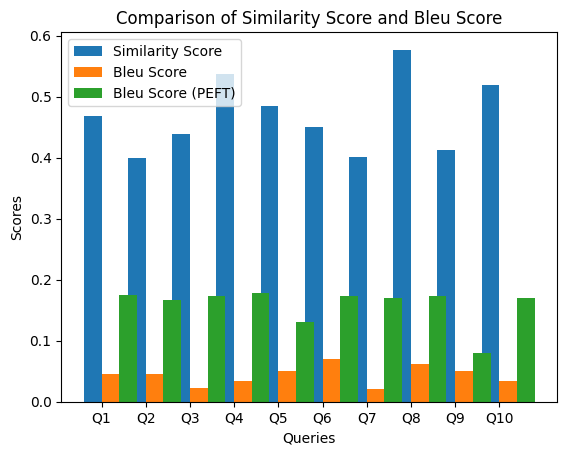

<Figure size 640x480 with 0 Axes>

In [97]:
from IPython.display import display, Markdown
from ragas.metrics.collections import BleuScore

scorer = BleuScore()
user_id = "evaluate_user"
config = {"configurable": {"thread_id": "1", "user_id": user_id}}
queries = [
    ("Rekomendasikan Minuman segar", "Kalau kamu mau makan Minuman segar, ada rekomendasi bagus nih! Coba deh ke 330 Kopi, Ciledug"),
    ("Rekomendasikan Sate", "Kalau kamu mau makan Sate, ada rekomendasi bagus nih! Coba deh ke Hedon Cafe, Sukatani"),
    ("Rekomendasikan Martabak", "Kalau kamu mau makan Martabak, ada rekomendasi bagus nih! Coba deh ke Markobar, Duren Sawit"),
    ("Rekomendasikan Japanese Food", "Kalau kamu mau makan Japanese Food, ada rekomendasi bagus nih! Coba deh ke Noodle Bar, Mojopahit"),
    ("Rekomendasikan Nasi Goreng", "Kalau kamu mau makan Nasi Goreng, ada rekomendasi bagus nih! Coba deh ke 330 KopRakoes Mulyorejo"),
    ("Rekomendasikan Bakso", "Kalau kamu mau makan Bakso, ada rekomendasi bagus nih! Coba deh ke Bakso Titoti, Parung"),
    ("Rekomendasikan Soto", "Kalau kamu mau makan Soto, ada rekomendasi bagus nih! Coba deh ke Joglo Sewu Roso"),
    ("Rekomendasikan Ayam", "Kalau kamu mau makan Ayam, ada rekomendasi bagus nih! Coba deh ke Yasaka Fried Chicken, Sukolegok"),
    ("Rekomendasikan Mie", "Kalau kamu mau makan Mie, ada rekomendasi bagus nih! Coba deh ke WARMINDO CJDW"),
    ("Rekomendasikan Dessert", "Kalau kamu mau makan Dessert, ada rekomendasi bagus nih! Coba deh ke K'bon Cafe")
]
import matplotlib.pyplot as plt
similarity_scores = []
bleu_scores = []
bleu_scores_peft = []

results = []
for q, ground_truth in queries:
    res = await app.ainvoke({"query": q, "k": 3}, config=config)
    similarity_scores.append(res['score'])
    bleu_scores.append(res['bleu_score'])
    
    answer_rag = res["answer"][0].content if isinstance(res["answer"], list) else str(res["answer"])
    answer_llm = res["llm_answer"][0].content if isinstance(res["llm_answer"], list) else str(res["llm_answer"])
    answer_peft = res["peft_answer"]
    
    score_res = await scorer.ascore(reference=ground_truth, response=answer_peft)
    print(f"ground truth: \n{ground_truth}")
    print("-" * 50)
    print(f"answer peft: \n{answer_peft}")
    print("=" * 50)
    bleu_val_peft = score_res.value if hasattr(score_res, "value") else float(score_res)
    bleu_scores_peft.append(bleu_val_peft)  
    results.append({
        "query": q,
        "retrieved_documents": "\n".join(res["retrieved"]),
        "answer_rag": answer_rag,
        "answer_llm": answer_llm,
        "answer_peft": answer_peft,
        "similarity_score": res['score'],
        "bleu_score": res['bleu_score'],
    })
    # Display results
    # display(Markdown(f"## Query: {q}"))
    # display(Markdown(f"### Similarity Score: {res['score']:.4f}"))
    # display(Markdown(f"### Bleu Score: {res['bleu_score']:.4f}"))
    # display(Markdown(f"### Jawaban RAG:\n{answer_rag}"))
    # display(Markdown(f"### Jawaban LLM:\n{answer_llm}"))

# Plot comparison chart
x = range(len(queries))
plt.bar(x, similarity_scores, width=0.4, label='Similarity Score', align='center')
plt.bar([i + 0.4 for i in x], bleu_scores, width=0.4, label='Bleu Score', align='center')
plt.bar([i + 0.8 for i in x], bleu_scores_peft, width=0.4, label='Bleu Score (PEFT)', align='center')
plt.xticks([i + 0.2 for i in x], [f"Q{i+1}" for i in x])
plt.xlabel('Queries')
plt.ylabel('Scores')
plt.title('Comparison of Similarity Score and Bleu Score')
plt.legend()
plt.savefig('advanced_rag_score_comparison.png')
plt.show()

# Export results to CSV
import csv
with open('advanced_rag_evaluation_results.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=["query", "retrieved_documents", "answer_rag", "answer_llm", "answer_peft", "similarity_score", "bleu_score"])
    writer.writeheader()
    for row in results:
        writer.writerow(row)